# Loading the needed libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import scipy.stats as ss
import plotly.express as px
import researchpy as rp

# Extra Analysis

     perc_gas  perc_elec
0   24.433498   4.847291
1   28.322197   5.270973
2   30.655468   5.824356
3   32.248521   6.564349
4   34.646643   7.014134
..        ...        ...
67  42.250000  43.555556
68  43.138236  41.795898
69  43.378615  40.953413
70  41.793893  43.268563
71  41.512518  43.345092

[72 rows x 2 columns]


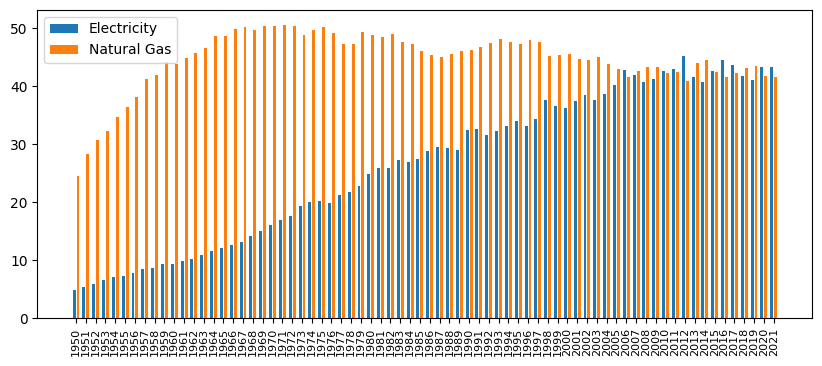

In [2]:
eia = pd.read_csv(r"residential-energy-consumption-by-source.csv", skiprows= 5)
eia["total"] = eia.select_dtypes(include = ["float64"]).sum(axis=1)
# the unit is Btu
eia["perc_gas"] = (eia["natural gas"]/eia["total"])*100
eia["perc_elec"] = (eia["electricity"]/ eia["total"])*100
print(eia[["perc_gas", "perc_elec"]])
plt.figure(figsize=(10,4))
plt.bar(np.arange(eia.shape[0])-0.2, eia["perc_elec"],width = 0.3, label = "Electricity")
plt.bar(np.arange(eia.shape[0])+0.2, eia["perc_gas"],width = 0.3, label = "Natural Gas")
plt.xticks(np.arange(eia.shape[0]), eia["year"], fontsize = 8, rotation = 90)
plt.legend(loc = "upper left")
plt.show()

In [3]:
eia.head()

,year,coal,natural gas,petroleum,renewables,electricity,total,perc_gas,perc_elec
0,1950,1.261,1.240,1.322,1.006,0.246,5.075,24.433498,4.847291
1,1951,1.159,1.526,1.461,0.958,0.284,5.388,28.322197,5.270973
2,1952,1.079,1.679,1.501,0.899,0.319,5.477,30.655468,5.824356
3,1953,0.966,1.744,1.511,0.832,0.355,5.408,32.248521,6.564349
4,1954,0.858,1.961,1.644,0.800,0.397,5.660,34.646643,7.014134


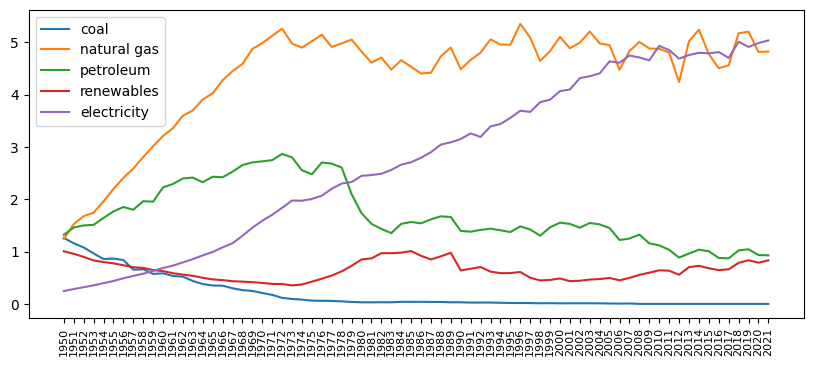

In [4]:
plt.figure(figsize=(10,4))
plt.plot(eia["year"],eia["coal"], label = "coal")
plt.plot(eia["year"],eia["natural gas"], label = "natural gas")
plt.plot(eia["year"],eia["petroleum"], label = "petroleum")
plt.plot(eia["year"],eia["renewables"], label = "renewables")
plt.plot(eia["year"],eia["electricity"], label = "electricity")
plt.xticks(eia["year"], fontsize = 8, rotation = 90)
plt.legend(loc = "upper left")
plt.show()

In [5]:
eia_TFC = pd.read_csv(r"Total final consumption (TFC) by sector - World.csv", skiprows=3)
eia_TFC.rename(columns = {"Unnamed: 0":"year"}, inplace=True)
exclude_columns = ["year", "Units"]
eia_TFC["total"] = eia_TFC.drop(columns=exclude_columns).sum(axis=1)
names = eia_TFC.select_dtypes(include= ["number"]).drop(columns= ["year","total"]).columns.tolist()

for name in names:
    eia_TFC[f"{name}_per"] = (eia_TFC[name] / eia_TFC["total"])*100
    eia_TFC.drop(columns = [name],inplace = True)
 
    
eia_TFC.head()

,year,Units,total,Non-energy use_per,Transport Sector_per,Industry Sector_per,Commercial and Public Services_per,Residential_per,Agriculture/Forestry_per,Fishing_per,Non-specified (Other)_per
0,1990,TJ,258650171,7.716682,25.545243,29.078242,7.231020,23.507107,2.647784,0.100547,4.173375
1,1991,TJ,261401196,7.869607,25.479132,28.649056,7.359731,23.696787,2.664097,0.102426,4.179165
2,1992,TJ,260480923,8.040629,26.119506,28.204753,7.175218,23.808513,2.562358,0.106893,3.982130
3,1993,TJ,262102798,7.825250,26.218456,27.720038,7.543992,25.962225,2.638492,0.099167,1.992380
4,1994,TJ,263335016,8.055770,26.613594,27.531426,7.708135,25.519314,2.681090,0.099608,1.791064


In [6]:
gas_eia = pd.read_csv(r"Natural gas final consumption by sector - World.csv",skiprows=3)
gas_eia.rename(columns = {"Unnamed: 0":"year"}, inplace=True)
exclude_columns = ["year", "Units"]
gas_eia["total"] = gas_eia.drop(columns=exclude_columns).sum(axis=1)
names = gas_eia.select_dtypes(include= ["number"]).drop(columns= ["year","total"]).columns.tolist()

for name in names:
    gas_eia[f"{name}_per"] = (gas_eia[name] / gas_eia["total"])*100
    gas_eia.drop(columns = [name],inplace = True)

gas_eia.head()

,year,Units,total,Non-energy use_per,Transport Sector_per,Industry Sector_per,Commercial and Public Services_per,Residential_per,Agriculture/Forestry_per,Fishing_per,Non-specified (Other)_per
0,1990,TJ gross,43951935,9.426541,5.992105,38.368711,11.986337,29.407781,0.795408,0.000164,4.022954
1,1991,TJ gross,44738655,9.329684,6.055723,36.809095,12.349786,30.615831,0.827463,0.000170,4.012248
2,1992,TJ gross,44404359,9.718933,6.171703,35.906826,12.347545,31.087423,0.715621,0.000173,4.051776
3,1993,TJ gross,45546771,9.496662,6.074804,34.479746,12.443758,33.038968,0.697821,0.000178,3.768063
4,1994,TJ gross,45402586,9.182358,6.036147,35.050167,12.912701,32.677053,0.642466,0.000187,3.498922


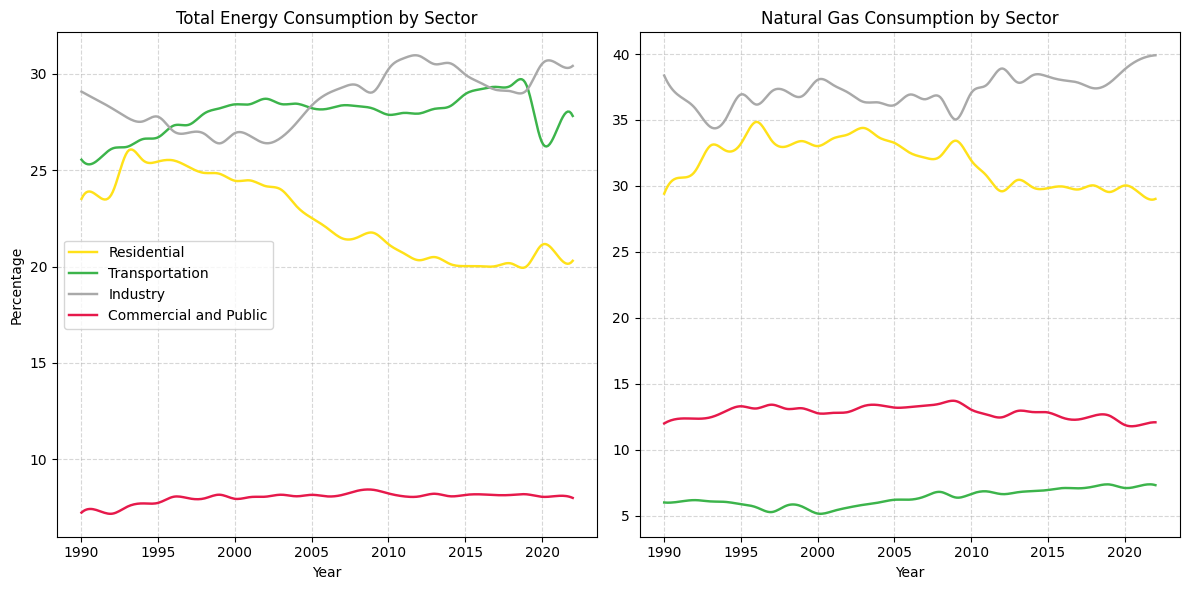

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline  # For smoothing

# Example data
x_0 = eia_TFC["year"]
x_1 = gas_eia["year"]
y1_0 = eia_TFC["Residential_per"]
y2_0 = eia_TFC["Transport Sector_per"]
y3_0 = eia_TFC["Industry Sector_per"]
y4_0 = eia_TFC["Commercial and Public Services_per"]
y1_1 = gas_eia["Residential_per"]
y2_1 = gas_eia["Transport Sector_per"]
y3_1 = gas_eia["Industry Sector_per"]
y4_1 = gas_eia["Commercial and Public Services_per"]

# Smooth the data using interpolation
x_0_smooth = np.linspace(x_0.min(), x_0.max(), 300)  # More points for smoothness
x_1_smooth = np.linspace(x_1.min(), x_1.max(), 300)  # More points for smoothness
y1_0_smooth = make_interp_spline(x_0, y1_0)(x_0_smooth)
y2_0_smooth = make_interp_spline(x_0, y2_0)(x_0_smooth)
y3_0_smooth = make_interp_spline(x_0, y3_0)(x_0_smooth)
y4_0_smooth = make_interp_spline(x_0, y4_0)(x_0_smooth)
y1_1_smooth = make_interp_spline(x_0, y1_1)(x_1_smooth)
y2_1_smooth = make_interp_spline(x_0, y2_1)(x_1_smooth)
y3_1_smooth = make_interp_spline(x_0, y3_1)(x_1_smooth)
y4_1_smooth = make_interp_spline(x_0, y4_1)(x_1_smooth)

# Plot with vivid colors and fixed subplots
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12, 6))

# Left subplot: Total energy consumption
ax[0].plot(x_0_smooth, y1_0_smooth,color = "#FFE119", label="Residential", linewidth=1.75)
ax[0].plot(x_0_smooth, y2_0_smooth,color = "#3CB44B", label="Transportation", linewidth=1.75)
ax[0].plot(x_0_smooth, y3_0_smooth,color = "#A9A9A9", label="Industry", linewidth=1.75)
ax[0].plot(x_0_smooth, y4_0_smooth,color = "#E6194B", label="Commercial and Public", linewidth=1.75)

ax[0].set_title("Total Energy Consumption by Sector", fontsize=12)
ax[0].set_xlabel("Year", fontsize=10)
ax[0].set_ylabel("Percentage", fontsize=10)
ax[0].grid(True, linestyle="--", alpha=0.5)
ax[0].legend(loc="best")

# Right subplot: Example duplicate for demonstration
ax[1].plot(x_1_smooth, y1_1_smooth,color = "#FFE119", label="Residential", linewidth=1.75)
ax[1].plot(x_1_smooth, y2_1_smooth,color = "#3CB44B", label="Transportation", linewidth=1.75)
ax[1].plot(x_1_smooth, y3_1_smooth,color = "#A9A9A9", label="Industry", linewidth=1.75)
ax[1].plot(x_1_smooth, y4_1_smooth,color = "#E6194B", label="Commercial and Public", linewidth=1.75)
ax[1].set_title("Natural Gas Consumption by Sector", fontsize=12)
ax[1].set_xlabel("Year", fontsize=10)
ax[1].grid(True, linestyle="--", alpha=0.5)

# Tight layout for better spacing
plt.tight_layout()

# Show the plot
plt.show()



In [8]:
eia_TFC = pd.read_csv(r"Total final consumption (TFC) by sector - World.csv", skiprows=3)
eia_TFC.rename(columns = {"Unnamed: 0":"year"}, inplace=True)
gas_eia = pd.read_csv(r"Natural gas final consumption by sector - World.csv",skiprows=3)
gas_eia.rename(columns = {"Unnamed: 0":"year"}, inplace=True)
print(
    eia_TFC.head(),
    gas_eia.head()
)

   year  Non-energy use  Transport Sector  Industry Sector  \
0  1990        19959212          66072815         75210922   
1  1991        20571248          66602755         74888974   
2  1992        20944305          68036330         73468000   
3  1993        20510200          68719308         72654995   
4  1994        21213662          70082912         72499885   

   Commercial and Public Services  Residential  Agriculture/Forestry  Fishing  \
0                        18703045     60801173               6848498   260064   
1                        19238425     61943684               6963982   267742   
2                        18690075     62016634               6674455   278436   
3                        19773013     68047717               6915562   259920   
4                        20298218     67201290               7060248   262302   

   Non-specified (Other) Units  
0               10794442    TJ  
1               10924386    TJ  
2               10372688    TJ  
3       

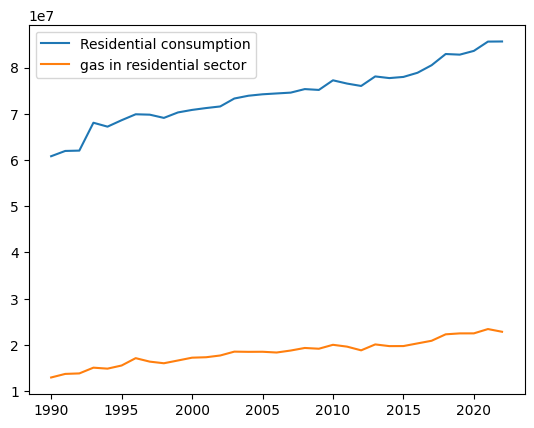

In [9]:
plt.plot(eia_TFC["year"],eia_TFC["Residential"], label = "Residential consumption")
plt.plot(gas_eia["year"], gas_eia["Residential"], label = "gas in residential sector")
plt.legend()
plt.show()

# 60 samples in Tehran for Calculating the share of natural gas in residential energy consumption

In [2]:
sample60 = pd.read_excel(r"C:\Users\Mahsa\Desktop\base\paper4\extra data\Sample.xlsx",dtype = {"Date1":"str", "Date2": "str","PostalCode": "str", "Eshterak_ID": "str",})
print(sample60.shape)
sample60.head()

(1024, 13)


,PostalCode,Id,Kontor_Id,Consumption,Date2,Date1,Period,Eshterak_ID,Apart_Number,Province,City,IsUrban,UsageType_ID
0,1131874411,10,45494407.0,38.0,1401/06/09,1401/04/23,49.0,3151864329,1.0,تهران,تهران,شهري,40.0
1,1131874411,10,45494407.0,39.0,1401/04/22,1401/03/12,42.0,3151864329,1.0,تهران,تهران,شهري,40.0
2,1131874411,10,45494407.0,123.0,1401/03/11,1401/01/24,50.0,3151864329,1.0,تهران,تهران,شهري,40.0
3,1131874411,10,6711832.0,120.0,1401/04/22,1401/03/12,42.0,3173708891,1.0,تهران,تهران,شهري,40.0
4,1131874411,10,6711832.0,21.0,1401/03/11,1401/01/24,50.0,3173708891,1.0,تهران,تهران,شهري,40.0


In [3]:
print(sample60.isna().sum())
sample60.dropna(subset=["Eshterak_ID"], inplace= True)
sample60["Period"] = sample60["Period"].round(0).astype("int")
print(sample60.isna().sum())

PostalCode        0
Id                0
Kontor_Id       176
Consumption     165
Date2           165
Date1           165
Period          165
Eshterak_ID     165
Apart_Number    165
Province        165
City            165
IsUrban         165
UsageType_ID    165
dtype: int64
PostalCode       0
Id               0
Kontor_Id       11
Consumption      0
Date2            0
Date1            0
Period           0
Eshterak_ID      0
Apart_Number     0
Province         0
City             0
IsUrban          0
UsageType_ID     0
dtype: int64


In [4]:
sheet_date = pd.read_csv(r"C:\Users\Mahsa\Documents\ArcGIS\Projects\paper 4_gas\python_scripts_getting_data\dates.csv")  
sheet_date["dates"] = pd.to_datetime(sheet_date["miladi"])
sample60.drop(columns = ["Id"], inplace= True)
sample60_melted = pd.melt(
    sample60,
    id_vars=["PostalCode", "Kontor_Id", "Consumption", "Period", "Eshterak_ID", "Apart_Number", "Province",
             "City", "IsUrban", "UsageType_ID"],
    var_name="Date_name",
    value_name= "Date"
)
sample60_melted

,PostalCode,Kontor_Id,Consumption,Period,Eshterak_ID,Apart_Number,Province,City,IsUrban,UsageType_ID,Date_name,Date
0,1131874411,4.549441e+07,38.0,49,3151864329,1.0,تهران,تهران,شهري,40.0,Date2,1401/06/09
1,1131874411,4.549441e+07,39.0,42,3151864329,1.0,تهران,تهران,شهري,40.0,Date2,1401/04/22
2,1131874411,4.549441e+07,123.0,50,3151864329,1.0,تهران,تهران,شهري,40.0,Date2,1401/03/11
3,1131874411,6.711832e+06,120.0,42,3173708891,1.0,تهران,تهران,شهري,40.0,Date2,1401/04/22
4,1131874411,6.711832e+06,21.0,50,3173708891,1.0,تهران,تهران,شهري,40.0,Date2,1401/03/11
...,...,...,...,...,...,...,...,...,...,...,...,...
1713,1998885739,6.033011e+11,61.0,44,3251359732,1.0,تهران,تهران,شهري,40.0,Date1,1401/06/05
1714,1998885739,6.033011e+11,676.0,42,3251359732,1.0,تهران,تهران,شهري,40.0,Date1,1401/08/30
1715,1998885739,6.033011e+11,51.0,46,3251359732,1.0,تهران,تهران,شهري,40.0,Date1,1401/04/21
1716,1998885739,6.033011e+11,73.0,45,3251359732,1.0,تهران,تهران,شهري,40.0,Date1,1401/01/27


In [5]:
sample60_melted.agg(
    "nunique"
)

PostalCode       65
Kontor_Id       122
Consumption     521
Period           67
Eshterak_ID     123
Apart_Number     12
Province          2
City              2
IsUrban           2
UsageType_ID      4
Date_name         2
Date            324
dtype: int64

+ If we take the 2022 as the focued-year, we would have the uncertainty regarding the relationship between postal codes and eshterak ids. Moreover, we have to spend lots of time gathering the information of these 65 postal codes for 2022.
+ If we take the 2021 as the reference for electricity, it would increase the uncertainty. I think that the deviation is not significant.

In [6]:
postalcode_eshterak = sample60_melted.groupby(["PostalCode","Eshterak_ID","Apart_Number"]).aggregate(
    PostalCode = ("PostalCode","first"),
    Eshterak_ID = ("Eshterak_ID","first")
).reset_index(drop = True)
postalcode_eshterak

,PostalCode,Eshterak_ID
0,1131874411,3151864329
1,1131874411,3173706502
2,1131874411,3173708891
3,1154654961,3164965132
4,1343975631,3130149687
...,...,...
118,1966644513,3022283190
119,1981118178,3068506238
120,1985714354,3004988275
121,1995943544,3212038992


In [7]:
sample60_merge = pd.merge(sample60_melted, sheet_date, left_on = "Date", right_on="shamsi", how = "left")
number_NA = sample60_merge["dates"].isna().sum()
print(number_NA)
sample60_merge.head()

0


,PostalCode,Kontor_Id,Consumption,Period,Eshterak_ID,Apart_Number,Province,City,IsUrban,UsageType_ID,Date_name,Date,shamsi,miladi,dates
0,1131874411,45494407.0,38.0,49,3151864329,1.0,تهران,تهران,شهري,40.0,Date2,1401/06/09,1401/06/09,2022/08/31,2022-08-31
1,1131874411,45494407.0,39.0,42,3151864329,1.0,تهران,تهران,شهري,40.0,Date2,1401/04/22,1401/04/22,2022/07/13,2022-07-13
2,1131874411,45494407.0,123.0,50,3151864329,1.0,تهران,تهران,شهري,40.0,Date2,1401/03/11,1401/03/11,2022/06/01,2022-06-01
3,1131874411,6711832.0,120.0,42,3173708891,1.0,تهران,تهران,شهري,40.0,Date2,1401/04/22,1401/04/22,2022/07/13,2022-07-13
4,1131874411,6711832.0,21.0,50,3173708891,1.0,تهران,تهران,شهري,40.0,Date2,1401/03/11,1401/03/11,2022/06/01,2022-06-01


In [8]:
for esh in sample60_merge["Eshterak_ID"].unique():
    df = sample60_merge.loc[(sample60_merge["Eshterak_ID"]==esh) & (sample60_merge["Date_name"]=="Date1")]
    df = df.sort_values(["dates"], ascending= [True]).reset_index()
    dates = []
    consumption_perD = []
    for i in range(df.shape[0]):
        d = pd.date_range(start=df["dates"].iloc[i], periods= df["Period"].iloc[i])
        dates = list(dates + list(d))
        con_per_d = (df["Consumption"].iloc[i] / df["Period"].iloc[i])/df["Apart_Number"].iloc[i]
        c = [con_per_d]*df["Period"].iloc[i]
        consumption_perD = list(consumption_perD + list(c))
    df2 = pd.DataFrame({"dates": dates, f"{esh}":consumption_perD})
    sheet_date = sheet_date.merge(df2, on = "dates", how= "left")
        
sheet_date.head() 

,shamsi,miladi,dates,3151864329,3173708891,3173706502,3164965132,3130149687,3055926019,3279321807,...,3299510419,3082127384,3299510733,3093665232,3127051706,3022283190,3068506238,3004988275,3212038992,3251359732
0,1400/01/01,2021/03/21,2021-03-21,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1400/01/02,2021/03/22,2021-03-22,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1400/01/03,2021/03/23,2021-03-23,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1400/01/04,2021/03/24,2021-03-24,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1400/01/05,2021/03/25,2021-03-25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
sample60_final = pd.melt(sheet_date,id_vars = ["shamsi","miladi","dates"],var_name= "Eshterak_ID",value_name="gas")
print(sample60_final["gas"].isna().sum()/sample60_final.shape[0])
sample60_final = sample60_final[(sample60_final["dates"]>= '2022-01-01') & (sample60_final["dates"] < '2023-01-01')]
sample60_final["min_cons"] = sample60_final.groupby("Eshterak_ID")["gas"].transform('min')
sample60_final["total"] = sample60_final.groupby("Eshterak_ID")["gas"].transform("sum")
# it is similar to window function in SQL
# min can be ascribe to cooking or water heating
sample60_final["air_conditioning_gas"] = sample60_final["gas"] - sample60_final["min_cons"]
sample60_final.head()


0.5579908675799087


,shamsi,miladi,dates,Eshterak_ID,gas,min_cons,total,air_conditioning_gas
286,1400/10/11,2022/01/01,2022-01-01,3151864329,NaN,0.77551,1104.777778,NaN
287,1400/10/12,2022/01/02,2022-01-02,3151864329,NaN,0.77551,1104.777778,NaN
288,1400/10/13,2022/01/03,2022-01-03,3151864329,NaN,0.77551,1104.777778,NaN
289,1400/10/14,2022/01/04,2022-01-04,3151864329,NaN,0.77551,1104.777778,NaN
290,1400/10/15,2022/01/05,2022-01-05,3151864329,NaN,0.77551,1104.777778,NaN


In [2]:
temp = pd.read_csv(r"asos.csv")
temp["valid"] = pd.to_datetime(temp["valid"])
temp["dates"] = temp["valid"].dt.date
temp.loc[(temp["station"]== "OIBL") & (temp["dates"]== pd.to_datetime("2022-06-27 17:00:00")), "tmpc"] = np.nan
temp.loc[(temp["station"]== "OIKB") & (temp["dates"]== pd.to_datetime("2022-03-31 16:00:00")), "tmpc"] = np.nan
temp2 = temp.groupby(["station","dates"]).agg(
    station = ("station", "first"),
    dates = ("dates", "first"),
    avg_temp = ("tmpc", "mean")
).reset_index(drop = True)
print(temp2.head())
temp2 = temp2[temp2["station"]=="OIII"]
print(temp2.shape[0]==temp2["dates"].nunique()*temp2["station"].nunique())
print(temp2.groupby("station")["dates"].nunique())
temp2["dates"] = pd.to_datetime(temp2["dates"])
print(temp2.info())
temp2.head()

  station       dates   avg_temp
0    OIAA  2022-01-01  13.346154
1    OIAA  2022-01-02  12.920000
2    OIAA  2022-01-03  12.913043
3    OIAA  2022-01-04  11.166667
4    OIAA  2022-01-05  10.708333
True
station
OIII    365
Name: dates, dtype: int64
<class 'pandas.core.frame.DataFrame'>
Index: 365 entries, 11120 to 11484
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype         
---  ------    --------------  -----         
 0   station   365 non-null    object        
 1   dates     365 non-null    datetime64[ns]
 2   avg_temp  365 non-null    float64       
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 11.4+ KB
None


,station,dates,avg_temp
11120,OIII,2022-01-01,7.458333
11121,OIII,2022-01-02,6.428571
11122,OIII,2022-01-03,6.041667
11123,OIII,2022-01-04,6.395833
11124,OIII,2022-01-05,6.425532


In [11]:
sample60_final= sample60_final.merge(temp2, on = "dates", how = "left")
sample60_final.head()

,shamsi,miladi,dates,Eshterak_ID,gas,min_cons,total,air_conditioning_gas,station,avg_temp
0,1400/10/11,2022/01/01,2022-01-01,3151864329,NaN,0.77551,1104.777778,NaN,OIII,7.458333
1,1400/10/12,2022/01/02,2022-01-02,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.428571
2,1400/10/13,2022/01/03,2022-01-03,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.041667
3,1400/10/14,2022/01/04,2022-01-04,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.395833
4,1400/10/15,2022/01/05,2022-01-05,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.425532


In [12]:
sample60_final["c_or_h"] = np.where(
    sample60_final["avg_temp"]<18, "heating", np.where(
        sample60_final["avg_temp"]>24, "cooling", pd.NA
    )
)
sample60_final.head()

,shamsi,miladi,dates,Eshterak_ID,gas,min_cons,total,air_conditioning_gas,station,avg_temp,c_or_h
0,1400/10/11,2022/01/01,2022-01-01,3151864329,NaN,0.77551,1104.777778,NaN,OIII,7.458333,heating
1,1400/10/12,2022/01/02,2022-01-02,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.428571,heating
2,1400/10/13,2022/01/03,2022-01-03,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.041667,heating
3,1400/10/14,2022/01/04,2022-01-04,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.395833,heating
4,1400/10/15,2022/01/05,2022-01-05,3151864329,NaN,0.77551,1104.777778,NaN,OIII,6.425532,heating


In [13]:
cooling_heating = sample60_final.groupby(["Eshterak_ID","c_or_h"], dropna= True).aggregate(
    Eshterak_ID = ("Eshterak_ID", "first"),
    cooling_heating = ("c_or_h", "first"),
    total_gas = ("total","first"),
    gas = ("air_conditioning_gas", "sum"),
    day_number = ("dates", "nunique"),
).reset_index(drop = True)
cooling_heating = pd.pivot(cooling_heating, index= ["Eshterak_ID","total_gas"], columns = "cooling_heating", values= "gas").reset_index(drop = False)
cooling_heating.columns.name = ""
cooling_heating

,Eshterak_ID,total_gas,cooling,heating
0,3004988275,2335.566327,108.504289,932.219488
1,3006167014,2845.225806,524.408653,864.219269
2,3006719923,2070.050000,105.312629,990.086783
3,3008555329,1258.189189,19.673263,565.997582
4,3022283190,1939.991429,56.187477,883.253427
...,...,...,...,...
118,3361652022,531.684211,141.200202,292.817173
119,3361652415,301.000000,157.043478,13.086957
120,3376610441,3119.947368,44.153361,1600.394147
121,3376903000,3270.970588,112.190000,2175.242406


In [14]:
sample60_postal = cooling_heating.merge(postalcode_eshterak, on = "Eshterak_ID", how = "inner") 
sample60_postal = sample60_postal.groupby("PostalCode").aggregate(
    total_gas = ("total_gas","mean"),
    cooling_gas = ("cooling", "mean"),
    heating_gas = ("heating","mean")
).reset_index(drop = False)
print(sample60_postal.shape)
sample60_postal.head()

(65, 4)


,PostalCode,total_gas,cooling_gas,heating_gas
0,1131874411,709.185185,98.607591,414.701045
1,1154654961,1352.892857,73.813905,741.889429
2,1343975631,436.214286,22.556843,281.514731
3,1344617593,953.942857,53.542420,603.402091
4,1346675737,713.000000,5.388132,347.650549


In [15]:
elec = pd.read_excel(r"C:\Users\Mahsa\Desktop\base\paper2\data14020230.xlsx")
elec2 = pd.read_excel(r"C:\Users\Mahsa\Desktop\base\paper2\14020225.xlsx", dtype = {"Postal_code":"str"})
elec2 = elec2[["ID","Postal_code","X","Y"]]
elect = elec.merge(elec2, on = "ID", how = "left")
elect = elect[["ID","Postal_code","E2020","E2021","cooling2020","cooling2021","heating2020","heating2021"]]
elect.head()

c:\Users\Mahsa\anaconda3\Lib\site-packages\openpyxl\worksheet\header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


,ID,Postal_code,E2020,E2021,cooling2020,cooling2021,heating2020,heating2021
0,46,1473677171,2829.291667,2829.247667,145.160000,533.430000,786.583667,411.605333
1,ZsKp,1471756649,3233.720000,3742.297667,175.050000,587.983667,142.430000,184.512000
2,132,1576833616,5621.253333,5116.160000,1666.870667,1643.728667,496.473333,144.117667
3,shYb,1475983555,2669.770000,2727.284000,89.520000,144.482000,168.880000,192.332000
4,R981,1966644513,2796.440000,2832.406333,614.262000,720.723667,331.362000,300.644333


In [16]:
energy_percentage = sample60_postal.merge(elect, left_on= "PostalCode", right_on= "Postal_code", how = "inner")
energy_percentage = energy_percentage[["PostalCode","total_gas","cooling_gas","heating_gas","cooling2021","heating2021","E2021"]]
energy_percentage.describe()

,total_gas,cooling_gas,heating_gas,cooling2021,heating2021,E2021
count,59.000000,59.000000,59.000000,59.000000,59.000000,59.000000
mean,1542.505814,79.382646,764.182393,709.132870,340.133605,3053.907819
std,948.060012,88.483214,369.693207,686.342302,279.618671,1203.259939
min,45.378947,5.388132,10.561100,20.295333,23.422333,703.608667
25%,939.588889,28.549962,488.936584,317.126000,118.399833,2352.901333
50%,1298.562500,53.542420,736.288752,559.257000,267.516667,2920.716333
75%,2035.658403,94.828692,897.521228,755.224667,496.954167,3521.015500
max,5832.754839,524.408653,2389.402965,3855.687333,1044.185000,6246.309000


In [17]:
energy_percentage["total_gas_Btu"] = energy_percentage["total_gas"] * 35315
energy_percentage["cooling_gas_Btu"] = energy_percentage["cooling_gas"] * 35315
energy_percentage["heating_gas_Btu"] = energy_percentage["heating_gas"] * 35315
energy_percentage["total_ele_Btu"] = energy_percentage["E2021"] * 3412
energy_percentage["cooling_ele_Btu"] = energy_percentage["cooling2021"] * 3412
energy_percentage["heating_ele_Btu"] = energy_percentage["heating2021"] * 3412

energy_percentage["total"] = energy_percentage["total_gas_Btu"] / (energy_percentage["total_gas_Btu"] + energy_percentage["total_ele_Btu"])
energy_percentage["cooling"] = energy_percentage["cooling_gas_Btu"] / (energy_percentage["cooling_gas_Btu"] + energy_percentage["cooling_ele_Btu"])
energy_percentage["heating"] = energy_percentage["heating_gas_Btu"] / (energy_percentage["heating_gas_Btu"] + energy_percentage["heating_ele_Btu"])

# Set display format to show numbers as integers without decimals
pd.options.display.float_format = '{:.2f}'.format
# pd.reset_option('display.float_format')
energy_percentage[["total","cooling","heating"]].describe()


,total,cooling,heating
count,59.00,59.00,59.00
mean,0.81,0.51,0.94
std,0.12,0.24,0.11
min,0.09,0.06,0.13
25%,0.77,0.32,0.93
50%,0.83,0.49,0.97
75%,0.88,0.72,0.98
max,0.96,0.97,1.00


In [18]:
# data comes from https://www.iea.org/data-and-statistics/data-tools/energy-statistics-data-browser?country=IRAN&energy=Balances&year=2022
# in Tj
# in 2022
gas = 2188548/ 2718700
electricity = 367857 / 2718700
print(gas, electricity)

0.8049979769742892 0.1353062125280465


# CDDs and HDDs
## Extracting the CDDs of stations all around our cases

In [2]:
directory = r"C:\Users\Mahsa\Desktop\base\paper4\cooling"
# Loop through all files in the directory
df = pd.DataFrame(columns= ["Date","CDD 24","% Estimated","name"])
for filename in os.listdir(directory):
    if filename.endswith(".csv"):  # Only process CSV files
        file_path = os.path.join(directory, filename)
        df1 = pd.read_csv(file_path, skiprows= 6,dtype={'CDD 24': 'float64', '% Estimated': 'int'})
        df1['Date'] = pd.to_datetime(df1['Date'])
        name = filename[:-4]
        df1['name'] = name
        df = pd.concat([df, df1], axis = 0)
        
data_cooling = df[(df["Date"]>= '2022-01-01') & (df["Date"] < '2023-01-01')].reset_index(drop=True)
data_cooling["join_name"] = data_cooling["name"].str.split("_", expand=True)[0]
print(data_cooling.head())
cooling = data_cooling.groupby("join_name").aggregate(
    name = ("name", "first"),
    join_name = ("join_name", "first"),
    CDD = ("CDD 24", "sum")
).reset_index(drop=True)
cooling


C:\Users\Mahsa\AppData\Local\Temp\ipykernel_5640\1768437788.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df1], axis = 0)


        Date  CDD 24 % Estimated           name join_name
0 2022-01-01     0.0           3  40704_CDD_24C     40704
1 2022-01-02     0.0           3  40704_CDD_24C     40704
2 2022-01-03     0.0           3  40704_CDD_24C     40704
3 2022-01-04     0.0           3  40704_CDD_24C     40704
4 2022-01-05     0.0           3  40704_CDD_24C     40704


,name,join_name,CDD
0,40704_CDD_24C,40704,180.0
1,40706_CDD_24C,40706,434.8
2,40710_CDD_24C,40710,180.2
3,40740_CDD_24C,40740,231.3
4,40741_CDD_24C,40741,981.8
5,40754_CDD_24C,40754,812.0
6,40794_CDD_24C,40794,1865.0
7,OIAI_CDD_24C,OIAI,2180.8
8,OIAM_CDD_24C,OIAM,2080.9
9,OIAW_CDD_24C,OIAW,2365.5


## Extracting the HDDs of stations all around our cases

In [3]:
directory = r"C:\Users\Mahsa\Desktop\base\paper4\heating"
# Loop through all files in the directory
df = pd.DataFrame(columns= ["Date","HDD 18","% Estimated","name"])
for filename in os.listdir(directory):
    if filename.endswith(".csv"):  # Only process CSV files
        file_path = os.path.join(directory, filename)
        df1 = pd.read_csv(file_path, skiprows= 6,dtype={'HDD 18': 'float64', '% Estimated': 'int'})
        df1['Date'] = pd.to_datetime(df1['Date'])
        name = filename[:-4]
        df1['name'] = name
        df = pd.concat([df, df1], axis = 0)
        
data_heating = df[(df["Date"]>= '2022-01-01') & (df["Date"] < '2023-01-01')].reset_index(drop=True)
data_heating["join_name"] = data_heating["name"].str.split("_", expand=True)[0]
print(data_heating.head())
heating = data_heating.groupby("join_name").aggregate(
    name = ("name", "first"),
    join_name = ("join_name", "first"),
    HDD = ("HDD 18", "sum")
).reset_index(drop=True)
heating

C:\Users\Mahsa\AppData\Local\Temp\ipykernel_5640\479919595.py:11: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df = pd.concat([df, df1], axis = 0)


        Date  HDD 18 % Estimated           name join_name
0 2022-01-01    19.0           3  40704_HDD_18C     40704
1 2022-01-02    17.6           3  40704_HDD_18C     40704
2 2022-01-03    19.4           3  40704_HDD_18C     40704
3 2022-01-04    17.8           3  40704_HDD_18C     40704
4 2022-01-05    17.1           3  40704_HDD_18C     40704


,name,join_name,HDD
0,40704_HDD_18C,40704,2811.6
1,40706_HDD_18C,40706,2594.4
2,40710_HDD_18C,40710,3626.9
3,40740_HDD_18C,40740,2660.9
4,40741_HDD_18C,40741,1393.9
5,40754_HDD_18C,40754,1341.2
6,40794_HDD_18C,40794,577.8
7,OIAI_HDD_18C,OIAI,502.2
8,OIAM_HDD_18C,OIAM,366.9
9,OIAW_HDD_18C,OIAW,398.3


## Extracting the Cooling and Heating Energy Consumpion using the temperature data
+ The calculation of HDDs and CDDs are based on "Integration Method".
+ In this regard, non zero value for HDD cannot be attributed to the average daily temperature less than 18 degree of Celsius.
+ With this in mind, temperature data (https://www.mesonet.agron.iastate.edu/request/download.phtml?network=IR__ASOS) is examined 

In [2]:
temp = pd.read_csv(r"asos.csv")
temp["valid"] = pd.to_datetime(temp["valid"])
print(temp.isna().sum())
print(temp.shape)
temp["date"] = temp["valid"].dt.date
temp.loc[(temp["station"]== "OIBL") & (temp["date"]== pd.to_datetime("2022-06-27 17:00:00")), "tmpc"] = np.nan
temp.loc[(temp["station"]== "OIKB") & (temp["date"]== pd.to_datetime("2022-03-31 16:00:00")), "tmpc"] = np.nan
temp.head()

station        0
valid          0
lon            0
lat            0
elevation      0
tmpc         128
dtype: int64
(693270, 6)


,station,valid,lon,lat,elevation,tmpc,date
0,OIBK,2022-01-01,53.9802,26.5262,30.0,18.0,2022-01-01
1,OIIP,2022-01-01,50.8267,35.7761,1271.0,1.0,2022-01-01
2,OING,2022-01-01,54.4700,36.8200,155.0,3.0,2022-01-01
3,OIMD,2022-01-01,58.6833,34.3500,1100.0,4.0,2022-01-01
4,OIKQ,2022-01-01,55.9023,26.7546,12.0,19.0,2022-01-01


  station        date   avg_temp
0    OIAA  2022-01-01  13.346154
1    OIAA  2022-01-02  12.920000
2    OIAA  2022-01-03  12.913043
3    OIAA  2022-01-04  11.166667
4    OIAA  2022-01-05  10.708333
True
False
station
OIAW    365
OIFK    337
OIFM    365
OIHR    319
OIIE    365
OIII    365
OIIP    365
OIMM    365
OISS    365
OITT    365
Name: date, dtype: int64


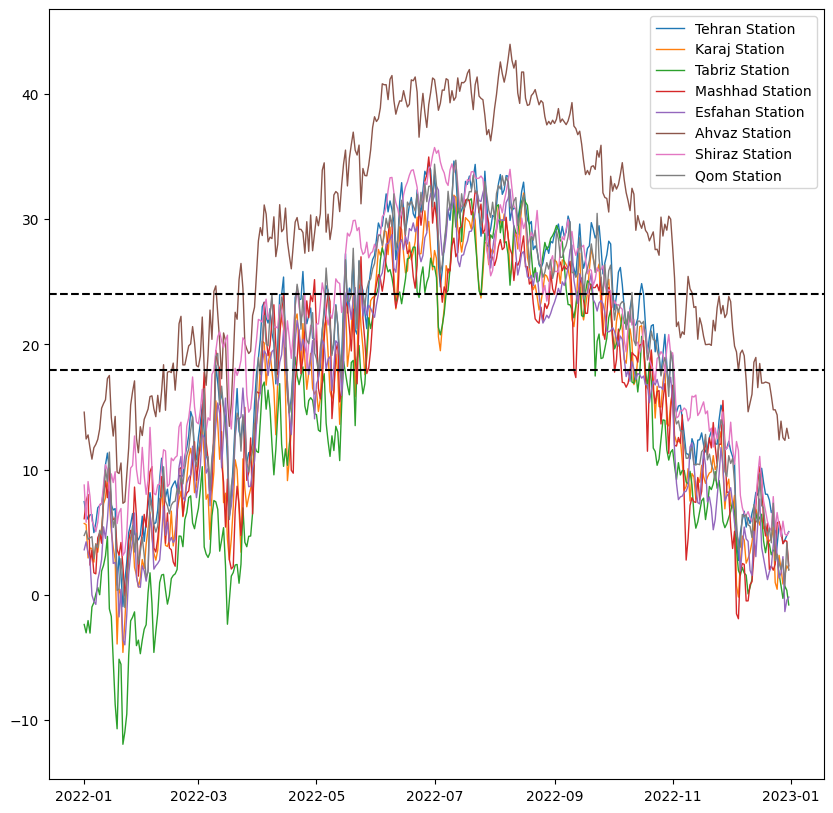

In [3]:
temp2 = temp.groupby(["station","date"]).agg(
    station = ("station", "first"),
    date = ("date", "first"),
    avg_temp = ("tmpc", "mean")
).reset_index(drop = True)
print(temp2.head())

name_list = ["OIII","OIIP","OITT","OIMM","OIFM","OIAW","OISS","OIIE","OIHR","OIFK"]
print(np.all(pd.Series(name_list).isin(temp2["station"].unique())))
temp2 = temp2[temp2["station"].isin(name_list)]
print(temp2.shape[0]==temp2["date"].nunique()*temp2["station"].nunique())
print(temp2.groupby("station")["date"].nunique())
temp2 = pd.pivot(temp2, index = "date", columns= "station", values= "avg_temp").reset_index(drop=True)
temp2.columns.name = ""
temp2["Date"] = pd.date_range("20220101", periods = 365, freq= "D")
temp2["Qom"] = temp2[["OIIE", "OIHR", "OIFK"]].mean(axis=1, skipna=True)
temp2 = temp2[["Date","OIII","OIIP","OITT","OIMM","OIFM","OIAW","OISS","Qom"]]
dic = {
    "OISS" : "Shiraz",
    "OIAW" : "Ahvaz",
    "OIFM" : "Esfahan",
    "OIII" : "Tehran",
    "OIIP" : "Karaj",
    "OITT" : "Tabriz",
    "OIMM" : "Mashhad"
}
temp2.rename(columns = dic, inplace = True)
eights = [col for col in temp2.columns if col != "Date"]
plt.figure(figsize=(10,10))
for name in eights:
    # Plot the original lines for each station
    plt.plot(temp2["Date"], temp2[name], linewidth=1, label=f"{name} Station")
    
    # Fill below 18
    #plt.fill_between(temp2["Date"], temp2[name], 18, where=(temp2[name] < 18), color='blue', alpha = 0.1, label="Below 18")
    
    # Fill above 24
    #plt.fill_between(temp2["Date"], 24, temp2[name], where=(temp2[name] > 24), color='red', alpha = 0.1, label="Above 24")
plt.axhline(18, color='black', linestyle='--')
plt.axhline(24, color='black', linestyle='--')
plt.legend()
plt.show()


In [4]:
temp2 = temp2.melt(id_vars="Date", value_name="avg_temp", var_name="city")
temp2.head()

,Date,city,avg_temp
0,2022-01-01,Tehran,7.458333
1,2022-01-02,Tehran,6.428571
2,2022-01-03,Tehran,6.041667
3,2022-01-04,Tehran,6.395833
4,2022-01-05,Tehran,6.425532


In [5]:
data_consumption = pd.read_csv(r"final_data.csv")
dates = pd.read_csv(r"dates.csv")
data_consumption["Date"] = pd.to_datetime(dates["miladi"])
data_consumption = data_consumption[(data_consumption["Date"]>= '2022-01-01') & (data_consumption["Date"] < '2023-01-01')].reset_index(drop=True)
data_consumption.columns
# consumption is per apartment per day

Index(['mean_11116', 'mean_11117', 'mean_11118', 'mean_11119', 'mean_11136',
       'mean_11137', 'mean_11138', 'mean_11139', 'mean_11146', 'mean_11147',
       ...
       'mean_91989', 'mean_91996', 'mean_91997', 'mean_91998', 'mean_91999',
       'mean_93516', 'mean_93517', 'mean_93518', 'mean_93519', 'Date'],
      dtype='object', length=2941)

In [6]:
gashts = pd.read_excel(r"eights.xlsx", dtype= {
    "sum_loan_h" : "int64",
    "gasht_name_str" : "object"
})
gashts = gashts[
    [
        'OBJECTID',
        'hh_count',
        'pop',
        'female_head_count',
        'mean_decile',
        'mean_hh_zise',
        'mean_oecd',
        'mean_loan_h',
        'sum_loan_h',
        'has_daramad_count',
        'mean_daramad',
        'mean_card1402',
        'HasPayed_count',
        'has_komite_count',
        'has_bonyad_count',
        'has_behzisti_count',
        'has_bazmandeh_count',
        'has_salmand_count',
        'has_under_5_count',
        'has_malool_count',
        'has_loan_count',
        'under_abs_line_hh_count',
        'under_severe_line_hh_count',
        'under_astaneh_line_hh_count',
        'under_abs_line_p_count',
        'under_severe_line_p_count',
        'under_astaneh_line_p_count',
        'IsBazmandeAzTahsil_count',
        'is_salmand_count',
        'is_under5_count',
        'is_loan_count',
        'mean_age',
        'mean_loan_p',
        'khali_winter',
        'khali_summer',
        'Kontor',
        'Apart',
        'city',
        'Shape_Length',
        'Shape_Area',
        'gasht_name_str'
    ]
]
gashts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2946 entries, 0 to 2945
Data columns (total 41 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   OBJECTID                     2946 non-null   int64  
 1   hh_count                     2946 non-null   int64  
 2   pop                          2946 non-null   int64  
 3   female_head_count            2946 non-null   int64  
 4   mean_decile                  2946 non-null   float64
 5   mean_hh_zise                 2946 non-null   float64
 6   mean_oecd                    2946 non-null   float64
 7   mean_loan_h                  2946 non-null   float64
 8   sum_loan_h                   2946 non-null   int64  
 9   has_daramad_count            2946 non-null   int64  
 10  mean_daramad                 2946 non-null   float64
 11  mean_card1402                2946 non-null   float64
 12  HasPayed_count               2946 non-null   int64  
 13  has_komite_count  

In [7]:
data_consumption_melt = pd.melt(data_consumption, id_vars= "Date", var_name= "gasht_name", value_name = "consumption")
print(data_consumption_melt.shape[0] == (data_consumption.shape[1]-1) * data_consumption["Date"].nunique())
print(data_consumption_melt.head())

city_gasht = gashts[["city","gasht_name_str"]]
data_consumption_melt["gasht"] = data_consumption_melt["gasht_name"].str.split("_", expand= True)[1]
data_consumption_melt = data_consumption_melt.merge(city_gasht, left_on= "gasht", right_on= "gasht_name_str", how = "left")
data_consumption_melt.head()

True
        Date  gasht_name  consumption
0 2022-01-01  mean_11116     6.489605
1 2022-01-02  mean_11116     6.489605
2 2022-01-03  mean_11116     7.970506
3 2022-01-04  mean_11116     7.734999
4 2022-01-05  mean_11116     6.930457


,Date,gasht_name,consumption,gasht,city,gasht_name_str
0,2022-01-01,mean_11116,6.489605,11116,Tehran,11116
1,2022-01-02,mean_11116,6.489605,11116,Tehran,11116
2,2022-01-03,mean_11116,7.970506,11116,Tehran,11116
3,2022-01-04,mean_11116,7.734999,11116,Tehran,11116
4,2022-01-05,mean_11116,6.930457,11116,Tehran,11116


In [8]:
data_consumption_melt["min_gasht"] = data_consumption_melt.groupby("gasht_name")["consumption"].transform('min') 
# it is similar to window function in SQL
# min can be ascribe to cooking or water heating
data_consumption_melt["air_conditioning_gas"] = data_consumption_melt["consumption"] - data_consumption_melt["min_gasht"]
data_consumption_melt.head()

,Date,gasht_name,consumption,gasht,city,gasht_name_str,min_gasht,air_conditioning_gas
0,2022-01-01,mean_11116,6.489605,11116,Tehran,11116,1.242475,5.247130
1,2022-01-02,mean_11116,6.489605,11116,Tehran,11116,1.242475,5.247130
2,2022-01-03,mean_11116,7.970506,11116,Tehran,11116,1.242475,6.728031
3,2022-01-04,mean_11116,7.734999,11116,Tehran,11116,1.242475,6.492524
4,2022-01-05,mean_11116,6.930457,11116,Tehran,11116,1.242475,5.687982


In [9]:
data_consumption_melt = data_consumption_melt.merge(temp2, on = ["Date", "city"], how = "left")
data_consumption_melt.head()

,Date,gasht_name,consumption,gasht,city,gasht_name_str,min_gasht,air_conditioning_gas,avg_temp
0,2022-01-01,mean_11116,6.489605,11116,Tehran,11116,1.242475,5.247130,7.458333
1,2022-01-02,mean_11116,6.489605,11116,Tehran,11116,1.242475,5.247130,6.428571
2,2022-01-03,mean_11116,7.970506,11116,Tehran,11116,1.242475,6.728031,6.041667
3,2022-01-04,mean_11116,7.734999,11116,Tehran,11116,1.242475,6.492524,6.395833
4,2022-01-05,mean_11116,6.930457,11116,Tehran,11116,1.242475,5.687982,6.425532


In [10]:
data_consumption_melt.shape[0]==(data_consumption_melt["Date"].nunique() * data_consumption_melt["gasht_name_str"].nunique())

True

In [11]:
data_consumption_melt["c_or_h"] = np.where(
    data_consumption_melt["avg_temp"]<18, "heating", np.where(
        data_consumption_melt["avg_temp"]>24, "cooling", pd.NA
    )
)
data_consumption_melt.head()

,Date,gasht_name,consumption,gasht,city,gasht_name_str,min_gasht,air_conditioning_gas,avg_temp,c_or_h
0,2022-01-01,mean_11116,6.489605,11116,Tehran,11116,1.242475,5.247130,7.458333,heating
1,2022-01-02,mean_11116,6.489605,11116,Tehran,11116,1.242475,5.247130,6.428571,heating
2,2022-01-03,mean_11116,7.970506,11116,Tehran,11116,1.242475,6.728031,6.041667,heating
3,2022-01-04,mean_11116,7.734999,11116,Tehran,11116,1.242475,6.492524,6.395833,heating
4,2022-01-05,mean_11116,6.930457,11116,Tehran,11116,1.242475,5.687982,6.425532,heating


In [12]:
data_consumption_melt["c_or_h"].isna().sum()

np.int64(197561)

In [13]:
df = gashts[["gasht_name_str","Apart"]]
df2 = data_consumption_melt.merge(df, on= "gasht_name_str", how = "left")
df2["c*apart"] = df2["consumption"] * df2["Apart"]
df3 = df2.groupby(["Date", "city"]).aggregate(
    city = ("city","first"),
    date = ("Date", "first"),
    ConApa = ("c*apart", "sum"),
    apart = ("Apart", "sum")
).reset_index(drop = True)
df3["average_daily_consumption_perUnit"] = df3["ConApa"]/df3["apart"]
df3.drop(columns = ["ConApa","apart"], inplace = True)
df3.head(8)

,city,date,average_daily_consumption_perUnit
0,Ahvaz,2022-01-01,2.195801
1,Esfahan,2022-01-01,5.878725
2,Karaj,2022-01-01,7.025230
3,Mashhad,2022-01-01,5.273707
4,Qom,2022-01-01,5.639209
5,Shiraz,2022-01-01,0.390677
6,Tabriz,2022-01-01,9.078877
7,Tehran,2022-01-01,6.852753


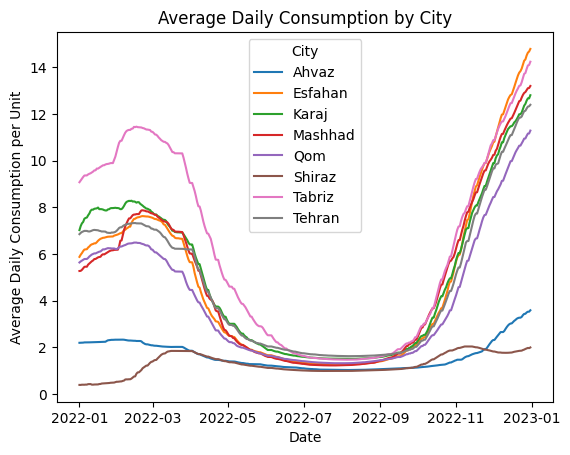

In [15]:
for city in df3["city"].unique():
    city_data = df3[df3["city"] == city]
    plt.plot(city_data["date"], city_data["average_daily_consumption_perUnit"], label=city)

plt.xlabel("Date")
plt.ylabel("Average Daily Consumption per Unit")
plt.title("Average Daily Consumption by City")
plt.legend(title="City")
plt.show()

In [16]:
temp2 = temp.groupby(["station","date"]).agg(
    station = ("station", "first"),
    date = ("date", "first"),
    avg_temp = ("tmpc", "mean")
).reset_index(drop = True)
print(temp2.head())

name_list = ["OIII","OIIP","OITT","OIMM","OIFM","OIAW","OISS","OIIE","OIHR","OIFK"]
temp2 = temp2[temp2["station"].isin(name_list)]
temp2 = pd.pivot(temp2, index = "date", columns= "station", values= "avg_temp").reset_index(drop=True)
temp2.columns.name = ""
temp2["Date"] = pd.date_range("20220101", periods = 365, freq= "D")
temp2["Qom"] = temp2[["OIIE", "OIHR", "OIFK"]].mean(axis=1, skipna=True)
temp2 = temp2[["Date","OIII","OIIP","OITT","OIMM","OIFM","OIAW","OISS","Qom"]]
dic = {
    "OISS" : "Shiraz",
    "OIAW" : "Ahvaz",
    "OIFM" : "Esfahan",
    "OIII" : "Tehran",
    "OIIP" : "Karaj",
    "OITT" : "Tabriz",
    "OIMM" : "Mashhad"
}
temp2.rename(columns = dic, inplace = True)

  station        date   avg_temp
0    OIAA  2022-01-01  13.346154
1    OIAA  2022-01-02  12.920000
2    OIAA  2022-01-03  12.913043
3    OIAA  2022-01-04  11.166667
4    OIAA  2022-01-05  10.708333


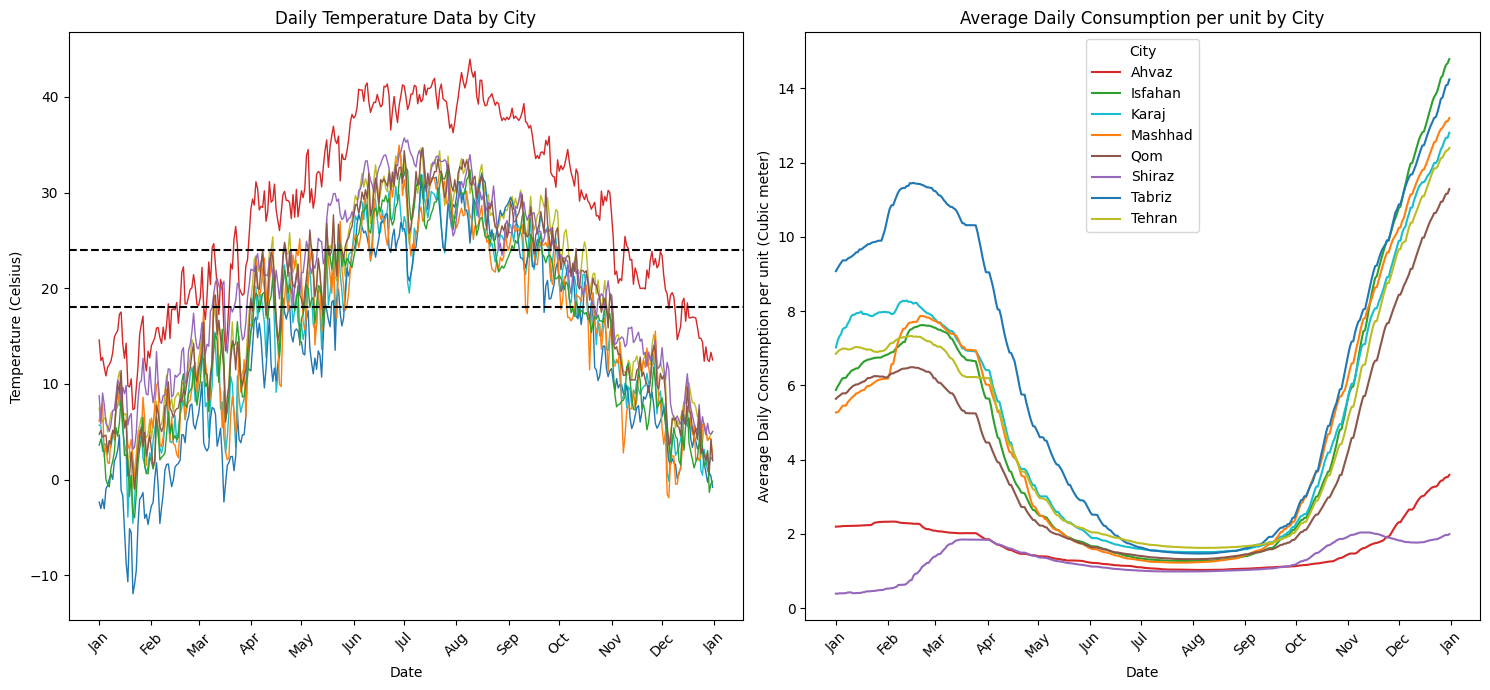

In [18]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.dates as mdates

# Rename 'Esfahan' to 'Isfahan' in the dataset
df3["city"] = df3["city"].replace("Esfahan", "Isfahan")
temp2.columns = [col.replace("Esfahan", "Isfahan") if col != "Date" else col for col in temp2.columns]

# Create a color map based on unique city/station names
unique_cities = df3["city"].unique()
unique_stations = temp2.columns[temp2.columns != "Date"]

# Combine all unique names to ensure consistent colors across plots
all_names = list(unique_cities) + list(unique_stations)
color_map = {name: cm.tab10(i % 10) for i, name in enumerate(all_names)}

# Create the subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 7))  # 1 row, 2 columns

# First plot: Grouped by city
for city in unique_cities:
    city_data = df3[df3["city"] == city]
    axes[1].plot(
        city_data["date"],
        city_data["average_daily_consumption_perUnit"],
        label=city,
        color=color_map[city]
    )
axes[1].set_title("Average Daily Consumption per unit by City")
axes[1].set_xlabel("Date")
axes[1].set_ylabel("Average Daily Consumption per unit (Cubic meter)")
axes[1].legend(title="City")

# Second plot: Station data
for station in unique_stations:
    axes[0].plot(
        temp2["Date"],
        temp2[station],
        linewidth=1,
        label=f"{station} Station",
        color=color_map[station]
    )
axes[0].axhline(18, color='black', linestyle='--')
axes[0].axhline(24, color='black', linestyle='--')
axes[0].set_title("Daily Temperature Data by City")
axes[0].set_ylabel("Temperature (Celsius)")
axes[0].set_xlabel("Date")

# Adjust layout and display
# Format x-axis to show months
for ax in axes:
    ax.xaxis.set_major_locator(mdates.MonthLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))  # e.g., Jan, Feb, ...
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()




In [21]:
cooling_heating = data_consumption_melt.groupby(["gasht_name_str","c_or_h"], dropna= True).aggregate(
    gasht_name_str = ("gasht_name_str", "first"),
    cooling_heating = ("c_or_h", "first"),
    energy = ("air_conditioning_gas", "sum"),
    day_number = ("Date", "nunique"),
).reset_index(drop = True)
cooling_heating = pd.pivot(cooling_heating, index= "gasht_name_str", columns = "cooling_heating", values= "energy").reset_index(drop = False)
cooling_heating.columns.name = ""
cooling_heating.head(10)

,gasht_name_str,cooling,heating
0,11116,21.741694,914.688925
1,11117,13.853787,855.604080
2,11118,24.772888,816.051719
3,11119,17.660779,895.459881
4,11136,19.261188,862.319093
5,11137,24.832804,924.704368
6,11138,17.617514,755.391270
7,11139,18.320356,1041.158626
8,11146,28.941479,1781.846794
9,11147,27.920588,749.336666


In [22]:
total_consumption = data_consumption_melt.groupby("gasht_name_str").aggregate(
    gasht_name_str = ("gasht_name_str", "first"),
    total_energy = ("consumption", "sum")
).reset_index(drop = True)
total_consumption["total_energy"].describe()

count    2940.000000
mean     1634.050335
std       631.234129
min       237.741573
25%      1370.149968
50%      1592.198724
75%      1900.540267
max      7669.280357
Name: total_energy, dtype: float64

# Loading other datasets and data preparation
## Interpolated CDDs and HDDs come from ArcGIS pro and spatial analysis 
+ EBK Regression Prediction (Geostatistical Analyst) -interpolating the temperature using DEM (90m resolution of Iran) raster file and then CDDs and HDDs utilizing previous outcome.
+ Zonal Statistic -mean value for each postal code.

In [24]:
cdd = pd.read_csv(r"CDD.csv")
cdd = cdd[["gasht_name_str","MEAN"]]
cdd.rename(columns= {
    "MEAN": "CDD_interpolated"
}, inplace=True)
hdd = pd.read_csv(r"HDD.csv")
hdd = hdd[["gasht_name_str","MEAN"]]
hdd.rename(columns= {
    "MEAN": "HDD_interpolated"
}, inplace=True)
print(cdd, hdd)

      gasht_name_str  CDD_interpolated
0              15557        841.440308
1              16148        952.436096
2              18339        980.084595
3              13396        973.073975
4              15847        926.080200
...              ...               ...
2941           37189        994.605194
2942           37481        992.564211
2943           37198        999.455994
2944           37151        994.614672
2945           37181        996.999142

[2946 rows x 2 columns]       gasht_name_str  HDD_interpolated
0              15557       1353.948486
1              16148       1209.914429
2              18339       1191.710693
3              13396       1192.787720
4              15847       1246.728760
...              ...               ...
2941           37189       1450.380817
2942           37481       1454.305679
2943           37198       1441.275635
2944           37151       1451.798532
2945           37181       1442.951061

[2946 rows x 2 columns]


## Interpolated NDVI and NDBI come from google earth engine code using imagery techniques
+ Zonal statistic - median for each postal code

In [25]:
ndbi = pd.read_csv(r"NDBI.csv")
ndbi = ndbi[["gasht_name_str","MEDIAN"]]
ndbi.rename(columns= {
    "MEDIAN": "NDBI_interpolated"
}, inplace=True)
ndvi = pd.read_csv(r"NDVI.csv")
ndvi = ndvi[["gasht_name_str","MEDIAN"]]
ndvi.rename(columns= {
    "MEDIAN": "NDVI_interpolated"
}, inplace=True)
print(ndbi, ndvi)

      gasht_name_str  NDBI_interpolated
0              15557           0.032813
1              16148           0.081448
2              18339           0.069402
3              13396           0.059880
4              15847           0.104681
...              ...                ...
2941           37189           0.113270
2942           37481           0.062547
2943           37198           0.091996
2944           37151           0.039766
2945           37181           0.054885

[2946 rows x 2 columns]       gasht_name_str  NDVI_interpolated
0              15557           0.051632
1              16148           0.022884
2              18339           0.030745
3              13396           0.038860
4              15847           0.023997
...              ...                ...
2941           37189           0.015373
2942           37481           0.036013
2943           37198           0.025581
2944           37151           0.049452
2945           37181           0.040554

[2946 rows x 2

# Joining different datasets

In [41]:
gashts = pd.read_excel(r"eights.xlsx", dtype= {
    "sum_loan_h" : "int64",
    "gasht_name_str" : "object"
})
gashts = gashts[
    [
        'OBJECTID',
        'hh_count',
        'pop',
        'female_head_count',
        'mean_decile',
        'mean_hh_zise',
        'mean_oecd',
        'mean_loan_h',
        'sum_loan_h',
        'has_daramad_count',
        'mean_daramad',
        'mean_card1402',
        'HasPayed_count',
        'has_komite_count',
        'has_bonyad_count',
        'has_behzisti_count',
        'has_bazmandeh_count',
        'has_salmand_count',
        'has_under_5_count',
        'has_malool_count',
        'has_loan_count',
        'under_abs_line_hh_count',
        'under_severe_line_hh_count',
        'under_astaneh_line_hh_count',
        'under_abs_line_p_count',
        'under_severe_line_p_count',
        'under_astaneh_line_p_count',
        'IsBazmandeAzTahsil_count',
        'is_salmand_count',
        'is_under5_count',
        'is_loan_count',
        'mean_age',
        'mean_loan_p',
        'khali_winter',
        'khali_summer',
        'Kontor',
        'Apart',
        'city',
        'Shape_Length',
        'Shape_Area',
        'gasht_name_str'
    ]
]

In [46]:
### the number of apartments per kontor by city
df = gashts.groupby("city").agg(
    city = ("city", "first"),
    apartment = ("Apart", "sum"),
    gas_meter = ("Kontor", "sum")
).reset_index(drop= True)
df["ApartPerKontor"] = df["apartment"]/df["gas_meter"]
df

,city,apartment,gas_meter,ApartPerKontor
0,Ahvaz,332091.0,247057.0,1.344188
1,Esfahan,679380.0,485145.0,1.400365
2,Karaj,284786.0,174738.0,1.629789
3,Mashhad,1268274.0,1125004.0,1.127351
4,Qom,442517.0,319657.0,1.384349
5,Shiraz,619990.0,577761.0,1.073091
6,Tabriz,671515.0,588815.0,1.140452
7,Tehran,3649026.0,1741689.0,2.095108


In [47]:
gashts["pop_density"] = gashts["pop"]/(gashts["Shape_Area"]/10000)
gashts["percentage_hh_female_head"] = gashts["female_head_count"]/gashts["hh_count"]
gashts["percentage_over65_pop"] = gashts["is_salmand_count"]/gashts["pop"]
gashts["percentage_under5_pop"] = gashts["is_under5_count"]/gashts["pop"]
gashts["bankability"] = gashts["is_loan_count"]/gashts["pop"]
gashts["abs_poverty_perc"] = gashts["under_abs_line_p_count"] / gashts["pop"]
gashts["severe_poverty_perc"] = gashts["under_severe_line_p_count"] / gashts["pop"]
gashts["num_units_per_acre"] = gashts["Apart"]/(gashts["Shape_Area"]/10000)
gashts["active_kontor_winter_p"] = (1-(gashts["khali_winter"]/gashts["Kontor"]))*100
gashts["active_kontor_summer_p"] = (1-(gashts["khali_summer"]/gashts["Kontor"]))*100
gashts["ApartKontor"] = gashts["Apart"]/gashts["Kontor"]
data = gashts.drop(['OBJECTID',"has_komite_count","female_head_count",'mean_oecd','mean_loan_h', 'sum_loan_h',
                 "has_daramad_count","HasPayed_count","has_bazmandeh_count",'mean_daramad',
                 "has_salmand_count","has_under_5_count","has_malool_count",'has_loan_count',
                 "under_abs_line_hh_count","under_severe_line_hh_count","under_astaneh_line_hh_count",
                 "has_bonyad_count","has_behzisti_count","under_abs_line_p_count",
                 "under_severe_line_p_count","under_astaneh_line_p_count",
                 "IsBazmandeAzTahsil_count","is_salmand_count","is_under5_count",
                 "is_loan_count",'mean_loan_p',
                 "khali_winter","khali_summer","Shape_Length",
                 "Shape_Area"], axis=1)
data.rename(columns={
    "mean_hh_zise" : "household_size_avg"
}, inplace=True)
print(data.shape)
print(data.columns)
data.head()


(2946, 21)
Index(['hh_count', 'pop', 'mean_decile', 'household_size_avg', 'mean_card1402',
       'mean_age', 'Kontor', 'Apart', 'city', 'gasht_name_str', 'pop_density',
       'percentage_hh_female_head', 'percentage_over65_pop',
       'percentage_under5_pop', 'bankability', 'abs_poverty_perc',
       'severe_poverty_perc', 'num_units_per_acre', 'active_kontor_winter_p',
       'active_kontor_summer_p', 'ApartKontor'],
      dtype='object')


,hh_count,pop,mean_decile,household_size_avg,mean_card1402,mean_age,Kontor,Apart,city,gasht_name_str,...,percentage_hh_female_head,percentage_over65_pop,percentage_under5_pop,bankability,abs_poverty_perc,severe_poverty_perc,num_units_per_acre,active_kontor_winter_p,active_kontor_summer_p,ApartKontor
0,425,945,7.807059,2.223529,499791988.3,46.213675,211.0,606.0,Tehran,15557,...,0.310588,0.216931,0.014815,0.101587,0.093122,0.025397,134.314471,91.943128,96.208531,2.872038
1,3143,7854,6.636653,2.498886,357324280.7,41.194758,1425.0,3863.0,Tehran,16148,...,0.301623,0.122358,0.031576,0.117902,0.148587,0.030048,232.940945,91.368421,97.543860,2.710877
2,1533,4300,6.311155,2.804958,380430608.1,36.833098,1284.0,1925.0,Tehran,18339,...,0.223744,0.084651,0.041163,0.102093,0.213023,0.033721,100.890494,92.367601,96.651090,1.499221
3,1309,3681,6.335371,2.812070,406327516.2,37.018972,1018.0,1582.0,Tehran,13396,...,0.223071,0.082586,0.043738,0.125509,0.193969,0.023635,119.610087,87.524558,95.284872,1.554028
4,507,1218,7.625247,2.402367,495992970.2,42.559769,205.0,600.0,Tehran,15847,...,0.222880,0.148604,0.014778,0.101806,0.132184,0.041872,65.444707,90.243902,93.658537,2.926829


In [48]:
'''
data, cdd, hdd, ndvi, ndbi, cooling-heating, total_consumption
'''
print(data["gasht_name_str"].dtypes)
print(cdd["gasht_name_str"].dtypes)
print(hdd["gasht_name_str"].dtypes)
print(ndvi["gasht_name_str"].dtypes)
print(ndbi["gasht_name_str"].dtypes)
print(cooling_heating["gasht_name_str"].dtypes)
print(total_consumption["gasht_name_str"].dtypes)

cdd["gasht_name_str"] = cdd["gasht_name_str"].astype("str")
hdd["gasht_name_str"] = hdd["gasht_name_str"].astype("str")
ndvi["gasht_name_str"] = ndvi["gasht_name_str"].astype("str")
ndbi["gasht_name_str"] = ndbi["gasht_name_str"].astype("str")

object
object
object
object
object
object
object


In [49]:
print(
    cdd["gasht_name_str"].str.len().mean(),
    hdd["gasht_name_str"].str.len().mean(),
    ndvi["gasht_name_str"].str.len().mean(),
    ndbi["gasht_name_str"].str.len().mean(),
    data["gasht_name_str"].str.len().mean(),
    cooling_heating["gasht_name_str"].str.len().mean(),
    total_consumption["gasht_name_str"].str.len().mean()
)
print(
    np.all(cdd["gasht_name_str"].isin(data["gasht_name_str"])),
    np.all(hdd["gasht_name_str"].isin(data["gasht_name_str"])),
    np.all(ndvi["gasht_name_str"].isin(data["gasht_name_str"])),
    np.all(ndbi["gasht_name_str"].isin(data["gasht_name_str"])),
    np.all(cooling_heating["gasht_name_str"].isin(data["gasht_name_str"])),
    np.all(total_consumption["gasht_name_str"].isin(data["gasht_name_str"]))
)

5.0 5.0 5.0 5.0 5.0 5.0 5.0
True True True True True True


In [30]:
data = data.merge(cdd, on = "gasht_name_str", how = "left")
data = data.merge(hdd, on = "gasht_name_str", how="left")
data = data.merge(ndvi, on = "gasht_name_str", how="left")
data = data.merge(ndbi, on = "gasht_name_str", how="left")
data = data.merge(cooling_heating, on = "gasht_name_str", how="left")
data = data.merge(total_consumption, on = "gasht_name_str", how="left")

In [31]:
data.columns

Index(['hh_count', 'pop', 'mean_decile', 'household_size_avg', 'mean_card1402',
       'mean_age', 'Kontor', 'Apart', 'city', 'gasht_name_str', 'pop_density',
       'percentage_hh_female_head', 'percentage_over65_pop',
       'percentage_under5_pop', 'bankability', 'abs_poverty_perc',
       'severe_poverty_perc', 'num_units_per_acre', 'active_kontor_winter_p',
       'active_kontor_summer_p', 'ApartKontor', 'CDD_interpolated',
       'HDD_interpolated', 'NDVI_interpolated', 'NDBI_interpolated', 'cooling',
       'heating', 'total_energy'],
      dtype='object')

In [32]:
data.isna().sum()

hh_count                     0
pop                          0
mean_decile                  0
household_size_avg           0
mean_card1402                0
mean_age                     0
Kontor                       6
Apart                        6
city                         0
gasht_name_str               0
pop_density                  0
percentage_hh_female_head    0
percentage_over65_pop        0
percentage_under5_pop        0
bankability                  0
abs_poverty_perc             0
severe_poverty_perc          0
num_units_per_acre           6
active_kontor_winter_p       6
active_kontor_summer_p       6
ApartKontor                  6
CDD_interpolated             0
HDD_interpolated             0
NDVI_interpolated            0
NDBI_interpolated            0
cooling                      6
heating                      6
total_energy                 6
dtype: int64

In [31]:
data.to_csv("data_for_gis.csv")

In [32]:
data.drop(columns=["hh_count","pop","Kontor","Apart"],inplace=True)

In [33]:
data.to_pickle("data.pkl")

# Inferential Statistics

In [50]:
data = pd.read_pickle(r"data.pkl")
data.shape

(2946, 24)

+ Eliminate the missing values

In [51]:
data = data.dropna(axis = 0)
data["num_units_per_hectare"] = data["num_units_per_acre"]
data.drop(columns= ["num_units_per_acre"], inplace= True)
print(data.shape)
data.info()

(2940, 24)
<class 'pandas.core.frame.DataFrame'>
Index: 2940 entries, 0 to 2945
Data columns (total 24 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   mean_decile                2940 non-null   float64
 1   household_size_avg         2940 non-null   float64
 2   mean_card1402              2940 non-null   float64
 3   mean_age                   2940 non-null   float64
 4   city                       2940 non-null   object 
 5   gasht_name_str             2940 non-null   object 
 6   pop_density                2940 non-null   float64
 7   percentage_hh_female_head  2940 non-null   float64
 8   percentage_over65_pop      2940 non-null   float64
 9   percentage_under5_pop      2940 non-null   float64
 10  bankability                2940 non-null   float64
 11  abs_poverty_perc           2940 non-null   float64
 12  severe_poverty_perc        2940 non-null   float64
 13  active_kontor_winter_p     2940 non-null  

+ Correlation Matrix

+ There is a correlation between mean_age and household_size
+ There is a correlation between percentage_over65_pop and household_size
+ There is a correlation between percentage_under5_pop and household_size
+ There is a correlation between percentage_hh_female_head and household_size
+ There is a correlation between mean_card1402 and mean_decile

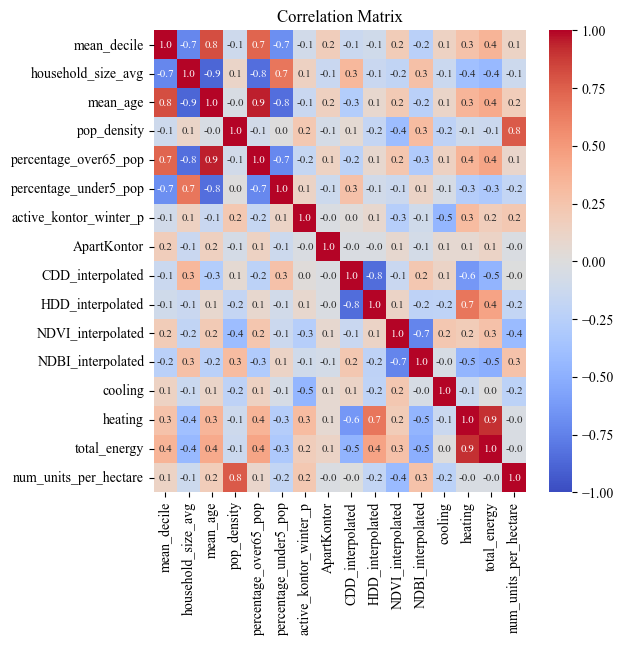

In [4]:
corr_matrix = data.select_dtypes(include=["number"]).drop(columns = ["percentage_hh_female_head",
                                                                     "mean_card1402",
                                                                     "abs_poverty_perc",
                                                                     "severe_poverty_perc",
                                                                     "bankability",
                                                                     "active_kontor_summer_p"]).corr()
plt.rcParams['font.family'] = 'Times New Roman'
plt.figure(figsize=(6,6))
sns.heatmap(corr_matrix, annot=True, fmt=".1f", cmap='coolwarm', vmin=-1, vmax=1, annot_kws={"size": 8})
plt.title('Correlation Matrix')
plt.show()

In [52]:
data2 = data.drop(columns = ["mean_age",
                            "percentage_over65_pop",
                            "abs_poverty_perc",
                            "severe_poverty_perc",
                            "bankability",
                            "percentage_under5_pop",
                            "percentage_hh_female_head",
                            "mean_card1402"])
data2["NDBI_interpolated"] = data2["NDBI_interpolated"]*100
data2["NDVI_interpolated"] = data2["NDVI_interpolated"]*100
print(data2.shape)
data2.describe(include=["number"]).round(2)

(2940, 16)


,mean_decile,household_size_avg,pop_density,active_kontor_winter_p,active_kontor_summer_p,ApartKontor,CDD_interpolated,HDD_interpolated,NDVI_interpolated,NDBI_interpolated,cooling,heating,total_energy,num_units_per_hectare
count,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00,2940.00
mean,6.72,2.67,176.79,82.30,93.93,2.33,873.95,1457.82,5.47,5.90,47.25,946.41,1634.05,74.62
std,0.96,0.24,152.19,20.44,4.36,4.99,374.41,460.63,3.74,4.03,44.92,412.68,631.23,55.44
min,3.67,1.96,0.08,0.00,42.86,1.00,174.21,377.69,0.70,-27.59,0.00,0.00,237.74,0.00
25%,6.11,2.51,74.97,83.81,92.50,1.28,727.34,1203.27,3.14,3.79,23.43,763.29,1370.15,30.44
50%,6.74,2.67,147.08,89.50,95.00,1.74,846.48,1353.95,4.46,6.57,32.02,940.29,1592.20,64.98
75%,7.47,2.82,255.27,92.35,96.54,2.46,963.94,1709.08,6.49,8.48,51.02,1184.55,1900.54,109.92
max,8.81,3.59,4467.60,100.00,100.00,239.00,2307.81,2957.05,38.78,16.32,616.15,2495.60,7669.28,270.62


In [53]:
data2.head()

,mean_decile,household_size_avg,city,gasht_name_str,pop_density,active_kontor_winter_p,active_kontor_summer_p,ApartKontor,CDD_interpolated,HDD_interpolated,NDVI_interpolated,NDBI_interpolated,cooling,heating,total_energy,num_units_per_hectare
0,7.807059,2.223529,Tehran,15557,209.450785,91.943128,96.208531,2.872038,841.440308,1353.948486,5.163245,3.281320,216.109995,848.319942,1277.038901,134.314471
1,6.636653,2.498886,Tehran,16148,473.600358,91.368421,97.543860,2.710877,952.436096,1209.914429,2.288438,8.144756,29.465940,785.997826,1376.067412,232.940945
2,6.311155,2.804958,Tehran,18339,225.365778,92.367601,96.651090,1.499221,980.084595,1191.710693,3.074468,6.940220,32.484787,874.388575,1536.785701,100.890494
3,6.335371,2.812070,Tehran,13396,278.308931,87.524558,95.284872,1.554028,973.073975,1192.787720,3.886039,5.988024,27.966089,737.793333,1305.871131,119.610087
4,7.625247,2.402367,Tehran,15847,132.852755,90.243902,93.658537,2.926829,926.080200,1246.728760,2.399711,10.468140,22.239996,939.255764,1620.413385,65.444707


In [ ]:
# the average ApartKontor across postal code regions. Thsi value in Tehran is 2.09
data2[data2["city"]=="Tehran"]["ApartKontor"].mean()

2.91529564935698

In [54]:
list_col = data2.select_dtypes(include="number").columns.tolist()
for col in list_col:
    data2[f"C_{col}"]  = data2[col] - data2[col].mean()
    data2.drop(columns = [col], inplace= True)
data2["C_N_pop_density"] = data2["C_pop_density"] / data["pop_density"].std()
data2["C_N_CDD_interpolated"] = data2["C_CDD_interpolated"] / data["CDD_interpolated"].std()
data2["C_N_HDD_interpolated"] = data2["C_HDD_interpolated"] / data["HDD_interpolated"].std()
data2["C_N_cooling"] = data2["C_cooling"] / data["cooling"].std()
data2["C_N_total_energy"] = data2["C_total_energy"] / data["total_energy"].std()
data2["C_N_heating"] = data2["C_heating"] / data["heating"].std()


data2.drop(columns= ["C_pop_density","C_CDD_interpolated","C_HDD_interpolated","C_cooling","C_heating","C_total_energy"], inplace= True)
data2.describe()

,C_mean_decile,C_household_size_avg,C_active_kontor_winter_p,C_active_kontor_summer_p,C_ApartKontor,C_NDVI_interpolated,C_NDBI_interpolated,C_num_units_per_hectare,C_N_pop_density,C_N_CDD_interpolated,C_N_HDD_interpolated,C_N_cooling,C_N_total_energy,C_N_heating
count,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03,2940.000000,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03,2.940000e+03
mean,-6.573729e-16,-3.238528e-16,-6.805743e-15,1.660833e-14,2.320140e-16,7.733798e-17,2.320140e-16,-3.712223e-15,0.000000,-4.736952e-16,2.706829e-16,1.933450e-17,-2.030122e-16,-2.223467e-16
std,9.551700e-01,2.363862e-01,2.044071e+01,4.363371e+00,4.986156e+00,3.736341e+00,4.030764e+00,5.544380e+01,1.000000,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
min,-3.053209e+00,-7.119256e-01,-8.229734e+01,-5.107399e+01,-1.330058e+00,-4.770663e+00,-3.348059e+01,-7.462159e+01,-1.161196,-1.868926e+00,-2.344874e+00,-1.051851e+00,-2.212030e+00,-2.293310e+00
25%,-6.050894e-01,-1.573013e-01,1.512180e+00,-1.431138e+00,-1.045229e+00,-2.336825e+00,-2.100329e+00,-4.418410e+01,-0.669071,-3.915759e-01,-5.526089e-01,-5.302074e-01,-4.180705e-01,-4.437467e-01
50%,1.791249e-02,3.393282e-03,7.201747e+00,1.068862e+00,-5.915459e-01,-1.008371e+00,6.758926e-01,-9.648413e+00,-0.195265,-7.339158e-02,-2.255021e-01,-3.389477e-01,-6.630125e-02,-1.483213e-02
75%,7.518882e-01,1.470104e-01,1.005081e+01,2.607346e+00,1.269479e-01,1.016315e+00,2.588404e+00,3.529305e+01,0.515659,2.403529e-01,5.454602e-01,8.392423e-02,4.221729e-01,5.770353e-01
max,2.093850e+00,9.174733e-01,1.770266e+01,6.068862e+00,2.366699e+02,3.330730e+01,1.042198e+01,1.959947e+02,28.194384,3.829659e+00,3.254701e+00,1.266415e+01,9.561001e+00,3.753926e+00


In [21]:
data2.to_pickle("data2.pkl")

In [22]:
data["total_energy"].std()

631.234128858001

In [23]:
data["heating"].std()

412.6840240769477

In [24]:
data2.to_csv("data.csv")